# Complete EDA of Google Playstore Apps Data
 

### About Dataset
__[ADVISORY] IMPORTANT__
### Instructions for citation:
If you use this dataset anywhere in your work, kindly cite as the below:
L. Gupta, "Google Play Store Apps," Feb 2019. [Online]. Available: https://www.kaggle.com/lava18/google-play-store-apps

### Context
While many public datasets (on Kaggle and the like) provide Apple App Store data, there are not many counterpart datasets available for Google Play Store apps anywhere on the web. On digging deeper, I found out that iTunes App Store page deploys a nicely indexed appendix-like structure to allow for simple and easy web scraping. On the other hand, Google Play Store uses sophisticated modern-day techniques (like dynamic page load) using JQuery making scraping more challenging.

### Content
Each app (row) has values for catergory, rating, size, and more.

### Acknowledgements
This information is scraped from the Google Play Store. This app information would not be available without it.

### Inspiration
The Play Store apps data has enormous potential to drive app-making businesses to success. Actionable insights can be drawn for developers to work on and capture the Android market!

## Importing important Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

__Important things to know__

In [2]:
# To show maximum rows and columns while printing the data
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
#ignoring warning
import warnings
warnings.filterwarnings('ignore')

## Loading data

In [3]:
df = pd.read_csv('./data/googleplaystore.csv')

### Loading 5 top rows of the data

In [4]:
df.head(5)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,7-Jan-18,1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,15-Jan-18,2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,1-Aug-18,1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,8-Jun-18,Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,20-Jun-18,1.1,4.4 and up


In [5]:
# Lets check out the columns
print(f'There are these columns {df.columns} in the data')
# Lets check out the number of columns and rows in the data
print(f'There are {df.shape[1]} columns and {df.shape[0]} rows in the data')


There are these columns Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object') in the data
There are 13 columns and 10841 rows in the data


In [6]:
# Now checking the info of data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10840 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  int64  
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10841 non-null  object 
 9   Genres          10840 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10839 non-null  object 
dtypes: float64(1), int64(1), object(11)
memory usage: 1.1+ MB


In [7]:
df.describe() # Here we can only see 2 numeric columns, However there are other numeric columns as well

,Rating,Reviews
count,9367.000000,1.084100e+04
mean,4.191513,4.441119e+05
std,0.515735,2.927629e+06
min,1.000000,0.000000e+00
25%,4.000000,3.800000e+01
50%,4.300000,2.094000e+03
75%,4.500000,5.476800e+04
max,5.000000,7.815831e+07


### We have following columns that need to be converted to numeric values  
1. Size
2. Installs
3. Price

# 1. Size 

In [8]:
df['Size'].unique()

array(['19M', '14M', '8.7M', '25M', '2.8M', '5.6M', '29M', '33M', '3.1M',
       '28M', '12M', '20M', '21M', '37M', '2.7M', '5.5M', '17M', '39M',
       '31M', '4.2M', '7.0M', '23M', '6.0M', '6.1M', '4.6M', '9.2M',
       '5.2M', '11M', '24M', 'Varies with device', '9.4M', '15M', '10M',
       '1.2M', '26M', '8.0M', '7.9M', '56M', '57M', '35M', '54M', '201k',
       '3.6M', '5.7M', '8.6M', '2.4M', '27M', '2.5M', '16M', '3.4M',
       '8.9M', '3.9M', '2.9M', '38M', '32M', '5.4M', '18M', '1.1M',
       '2.2M', '4.5M', '9.8M', '52M', '9.0M', '6.7M', '30M', '2.6M',
       '7.1M', '3.7M', '22M', '7.4M', '6.4M', '3.2M', '8.2M', '9.9M',
       '4.9M', '9.5M', '5.0M', '5.9M', '13M', '73M', '6.8M', '3.5M',
       '4.0M', '2.3M', '7.2M', '2.1M', '42M', '7.3M', '9.1M', '55M',
       '23k', '6.5M', '1.5M', '7.5M', '51M', '41M', '48M', '8.5M', '46M',
       '8.3M', '4.3M', '4.7M', '3.3M', '40M', '7.8M', '8.8M', '6.6M',
       '5.1M', '61M', '66M', '79k', '8.4M', '118k', '44M', '695k', '1.6M',
     

#### There are following observation in this column to be dealt with
1. M
2. k
3. Varies with device

In [9]:
# Checking if there are any null / missing values in Size
df['Size'].isnull().sum()

np.int64(0)

In [10]:
# How many values with 'M' 
df['Size'].loc[df['Size'].str.contains('M')].value_counts().sum() 

np.int64(8830)

In [11]:
# How many values with 'k' 
df['Size'].loc[df['Size'].str.contains('k')].value_counts().sum() 

np.int64(316)

In [12]:
# How many values with 'Varies with device' 
df['Size'].loc[df['Size'].str.contains('Varies with device')].value_counts().sum() 

np.int64(1695)

In [13]:
print(8830+316+1695) # We have 10841 total observations in the data 

10841


In [14]:
# This function will convert size values in bytes
def value_conversion(size):
    if isinstance(size, str):
        if 'M' in size:
            return float(size.replace('M', '') )* 1024 * 1024
        elif 'k' in size:
            return float( size.replace('k', '') )* 1024
        elif 'Varies with device' in size:
            return np.nan
    return size        

In [15]:
df['Size']= df['Size'].apply(value_conversion)
df['Size_in_Mbs'] = df['Size'].apply(lambda x: x / (1024*1024)) # Defining another column for size in Mbs

In [16]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_in_Mbs
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19922944.0,"10,000+",Free,0,Everyone,Art & Design,7-Jan-18,1.0.0,4.0.3 and up,19.0
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14680064.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,15-Jan-18,2.0.0,4.0.3 and up,14.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,9122611.2,"5,000,000+",Free,0,Everyone,Art & Design,1-Aug-18,1.2.4,4.0.3 and up,8.7
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,26214400.0,"50,000,000+",Free,0,Teen,Art & Design,8-Jun-18,Varies with device,4.2 and up,25.0
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2936012.8,"100,000+",Free,0,Everyone,Art & Design;Creativity,20-Jun-18,1.1,4.4 and up,2.8


# 2. Installs

In [17]:
# Checking the values in the this column
df['Installs'].unique()

array(['10,000+', '500,000+', '5,000,000+', '50,000,000+', '100,000+',
       '50,000+', '1,000,000+', '10,000,000+', '5,000+', '100,000,000+',
       '1,000,000,000+', '1,000+', '500,000,000+', '50+', '100+', '500+',
       '10+', '1+', '5+', '0+', '0'], dtype=object)

In [18]:
# Check if there are any null / missing values in the column
df['Installs'].isnull().sum() 

np.int64(0)

We have 0 null / missing values in this column so we are good to go.

We have following obserevation in this column values
1. '__+__'
2. ' __,__ '
3. __Data type of values__

We will use lambda function to remove the '+' & ',' signs and convert the data type to int

In [19]:
# Remove '+' sign
df['Installs'] = df['Installs'].apply(lambda x: x.replace('+', "") if str("+") in x else x) 

In [20]:
# Remove ',' sign
df['Installs'] = df['Installs'].apply(lambda x: x.replace(',', "") if str(",") in x else x) 

In [21]:
# Now we will convert it into integer data type
df['Installs'] = df['Installs'].apply(lambda x: int(x))

As of now installs values has been properly converted into integers, '+' and ',' signs have been removed. 

Now we will move to the next step 

# 3. Price

In [22]:
df["Price"].unique()

array(['0', '$4.99 ', '$3.99 ', '$6.99 ', '$1.49 ', '$2.99 ', '$7.99 ',
       '$5.99 ', '$3.49 ', '$1.99 ', '$9.99 ', '$7.49 ', '$0.99 ',
       '$9.00 ', '$5.49 ', '$10.00 ', '$24.99 ', '$11.99 ', '$79.99 ',
       '$16.99 ', '$14.99 ', '$1.00 ', '$29.99 ', '$12.99 ', '$2.49 ',
       '$10.99 ', '$1.50 ', '$19.99 ', '$15.99 ', '$33.99 ', '$74.99 ',
       '$39.99 ', '$3.95 ', '$4.49 ', '$1.70 ', '$8.99 ', '$2.00 ',
       '$3.88 ', '$25.99 ', '$399.99 ', '$17.99 ', '$400.00 ', '$3.02 ',
       '$1.76 ', '$4.84 ', '$4.77 ', '$1.61 ', '$2.50 ', '$1.59 ',
       '$6.49 ', '$1.29 ', '$5.00 ', '$13.99 ', '$299.99 ', '$379.99 ',
       '$37.99 ', '$18.99 ', '$389.99 ', '$19.90 ', '$8.49 ', '$1.75 ',
       '$14.00 ', '$4.85 ', '$46.99 ', '$109.99 ', '$154.99 ', '$3.08 ',
       '$2.59 ', '$4.80 ', '$1.96 ', '$19.40 ', '$3.90 ', '$4.59 ',
       '$15.46 ', '$3.04 ', '$4.29 ', '$2.60 ', '$3.28 ', '$4.60 ',
       '$28.99 ', '$2.95 ', '$2.90 ', '$1.97 ', '$200.00 ', '$89.99 ',
       '$2.56 '

We have following observations in the values of this column
1. $ sign
2. Data type is not float
3. Free apps which have 0 price 

Here will again used the same method we previously used to convert data types and removing unwanted string from values

In [23]:
# Remove $ sign from the values and also convert the data type to float
df['Price'] = df['Price'].apply(lambda x: float(x.replace('$', "")) if str("$") in x else float(x))


There is another method which we can use to perform above steps 

In [ ]:
# For $ sign
df['Price'].loc(df['Price'].str.contains('\$')).value_counts().sum()
# For 0 string value
(df['Price'].loc[df['Price'].str.contains('0')].value_counts().sum()) &(~df['Price'].loc[df['Price'].str.contains('\$')].value_counts().sum()) 

In [29]:
df['Price'].unique()

array([  0.  ,   4.99,   3.99,   6.99,   1.49,   2.99,   7.99,   5.99,
         3.49,   1.99,   9.99,   7.49,   0.99,   9.  ,   5.49,  10.  ,
        24.99,  11.99,  79.99,  16.99,  14.99,   1.  ,  29.99,  12.99,
         2.49,  10.99,   1.5 ,  19.99,  15.99,  33.99,  74.99,  39.99,
         3.95,   4.49,   1.7 ,   8.99,   2.  ,   3.88,  25.99, 399.99,
        17.99, 400.  ,   3.02,   1.76,   4.84,   4.77,   1.61,   2.5 ,
         1.59,   6.49,   1.29,   5.  ,  13.99, 299.99, 379.99,  37.99,
        18.99, 389.99,  19.9 ,   8.49,   1.75,  14.  ,   4.85,  46.99,
       109.99, 154.99,   3.08,   2.59,   4.8 ,   1.96,  19.4 ,   3.9 ,
         4.59,  15.46,   3.04,   4.29,   2.6 ,   3.28,   4.6 ,  28.99,
         2.95,   2.9 ,   1.97, 200.  ,  89.99,   2.56,  30.99,   3.61,
       394.99,   1.26,   1.2 ,   1.04])

In [ ]:
df.describe()

,Rating,Reviews,Size,Installs,Price,Size_in_Mbs
count,9367.000000,1.084100e+04,9.146000e+03,1.084100e+04,10841.000000,9146.000000
mean,4.191513,4.441119e+05,2.255921e+07,1.546291e+07,1.027273,21.514141
std,0.515735,2.927629e+06,2.368595e+07,8.502557e+07,15.948971,22.588679
min,1.000000,0.000000e+00,8.704000e+03,0.000000e+00,0.000000,0.008301
25%,4.000000,3.800000e+01,5.138022e+06,1.000000e+03,0.000000,4.900000
50%,4.300000,2.094000e+03,1.363149e+07,1.000000e+05,0.000000,13.000000
75%,4.500000,5.476800e+04,3.145728e+07,5.000000e+06,0.000000,30.000000
max,5.000000,7.815831e+07,1.048576e+08,1.000000e+09,400.000000,100.000000


**The tasks of converting the 3 column data  type to their actual data type is completed**

## Dealing with missing values

In [30]:
# finding that how many missing values are in the data in corresponding columns
df.isnull().sum().sort_values(ascending=False)

Size              1695
Size_in_Mbs       1695
Rating            1474
Current Ver          8
Android Ver          2
Category             1
Type                 1
Genres               1
App                  0
Reviews              0
Installs             0
Price                0
Content Rating       0
Last Updated         0
dtype: int64

In [31]:
# Find the percentage of missing values in the data
round(df.isnull().sum()/len(df)*100,2).sort_values(ascending=False)

Size              15.64
Size_in_Mbs       15.64
Rating            13.60
Current Ver        0.07
Android Ver        0.02
Category           0.01
Type               0.01
Genres             0.01
App                0.00
Reviews            0.00
Installs           0.00
Price              0.00
Content Rating     0.00
Last Updated       0.00
dtype: float64

In [32]:
# Total num of missing values
df.isnull().sum().sum()

np.int64(4877)

# Dealing missing values

In [33]:
# setting Plot size
plt.figure(figsize=(16,6))

<Figure size 1600x600 with 0 Axes>

<Figure size 1600x600 with 0 Axes>

<Axes: >

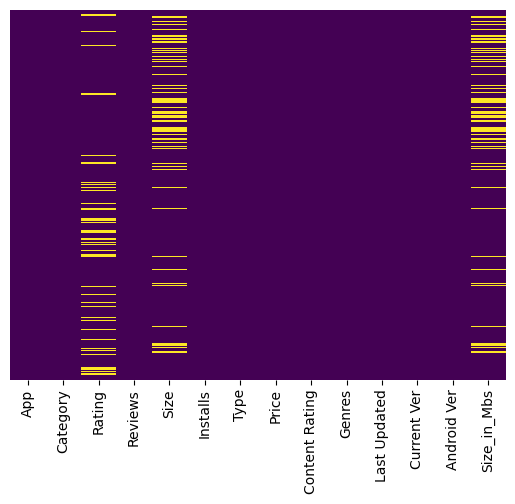

In [ ]:
# Plot of missing values in the data
sns.heatmap(df.isnull(), yticklabels=False, cbar = False, cmap='viridis')

Text(0.5, 1.0, 'Percentage of Missing Values in each Column')

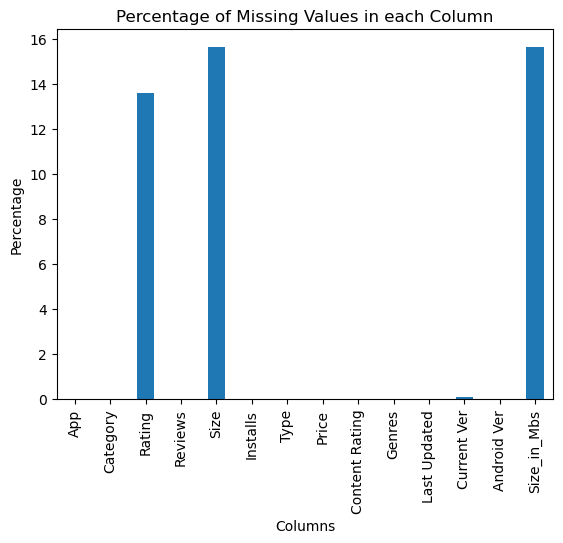

In [37]:
# Plot of percentage of missing values in the the columns of the data
missing_percentage = df.isnull().sum()/len(df)*100
missing_percentage.plot(kind= 'bar')
# Add Labels
plt.xlabel('Columns')
plt.ylabel('Percentage')
plt.title('Percentage of Missing Values in each Column')

<Axes: >

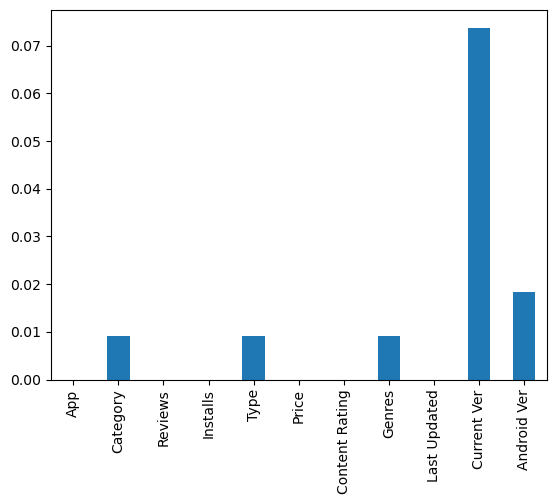

In [38]:
# Plotting only columns with less than 1% missing values
missing_percentage[missing_percentage < 1].plot(kind = 'bar')